# Multi-Class Classification of Network Traffic Without Scaling

This experiment evaluates multiple machine learning models for multi-class
network traffic classification without applying feature scaling.

The models evaluated include:

- Support Vector Machine (SVM)
- Decision Tree (DT)
- K-Nearest Neighbors (KNN)
- XGBoost
- Hybrid DT–SVM
- Hybrid KNN–SVM

Evaluation is performed using multiple train-test splits:
- 70–30
- 60–40
- 50–50
- 30–70

Performance metrics:
- Accuracy
- F1 Score
- Cohen's Kappa

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, 
                             roc_auc_score, cohen_kappa_score)
from sklearn.tree import DecisionTreeClassifier
# Add LinearSVC here
from sklearn.svm import SVC, LinearSVC 
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


## 2. Load the Dataset

In [19]:
df = pd.read_csv("preprocessed_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (221564, 37)


,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1484,1499,6,22,41410,6.472,113472,628,17532.756490,97.033375,...,0.0,113472,7295988,628,6659,628,1,10,0,5
1,1482,1501,6,41410,22,6.465,24492,370,3788.399072,57.231245,...,0.0,26080,24492,381,370,370,2,1,0,5
2,1486,1501,1,0,0,4.798,2211,4,460.817007,0.833681,...,0.0,28291,3799,385,15,0,3,2,0,3
3,1484,1503,17,57426,1236,595.270,10827817,25627,18189.757590,43.051052,...,0.0,188960322,180776253,157117,153898,30743,60,19,0,6
4,1484,1503,17,48549,1234,595.251,154551644,114704,259641.132900,192.698542,...,0.0,188960322,180776253,157117,153898,122654,60,19,0,6


# Balancing the dataset
## Since the dataset is highly imbalanced we undersample the classes with large number of rows

In [ ]:
target_per_class = 1000

dfs = []

for label in df["Category"].unique():

    class_df = df[df["Category"] == label]

    sampled_df = class_df.sample(
        n=min(len(class_df), target_per_class),
        random_state=42
    )

    dfs.append(sampled_df)

balanced_df = pd.concat(dfs, ignore_index=True)

print("Balanced distribution:")
print(balanced_df["Category"].value_counts())

# Splitting features and labels

In [12]:
X = df.drop("Category", axis=1)
y_multi = df["Category"]

## 4. Train-Test Splits

To evaluate model robustness, multiple train-test splits are used:
70-30, 60-40, 50-50 and 30-70.

In [28]:
splits = {
    "70-30": 0.30,
    "60-40": 0.40,
    "50-50": 0.50,
    "30-70": 0.70
}

## 5. Model Definitions

In [31]:


models = {

    "SVM": LinearSVC(
        random_state=42,
        dual=False,      # faster for large datasets
        max_iter=10000
    ),

    "DT": DecisionTreeClassifier(
        random_state=42,
        max_depth=20,    # prevents huge trees
        min_samples_split=5
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        algorithm="kd_tree",   # much faster neighbor search
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        objective="multi:softmax",
        num_class=len(y_multi.unique()),
        eval_metric="mlogloss",
        random_state=42,
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        tree_method="hist"     # huge speed improvement
    )
}

## 6. Hybrid Models

Two hybrid models are constructed to combine the strengths of
different machine learning algorithms.

In [32]:
from sklearn.ensemble import StackingClassifier

hybrid_dt_svm = StackingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(max_depth=20, random_state=42))
    ],
    final_estimator=LinearSVC(dual=False, max_iter=2000),
    cv=2,
    n_jobs=-1
)

hybrid_knn_svm = StackingClassifier(
    estimators=[
        ("knn", KNeighborsClassifier(n_neighbors=5, algorithm="kd_tree", n_jobs=-1))
    ],
    final_estimator=LinearSVC(dual=False, max_iter=2000),
    cv=2,
    n_jobs=-1
)

models["Hybrid DT-SVM"] = hybrid_dt_svm
models["Hybrid KNN-SVM"] = hybrid_knn_svm

## 7. Model Training and Evaluation

For each split:

1. Train each model
2. Evaluate using Accuracy, F1 Score and Cohen's 
3. Create a confusion matrix

In [33]:
# Now we train models on different split ratios and store the results in a dictionary (MULTICLASS)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import joblib, os

# folder to persist models
os.makedirs("saved_models", exist_ok=True)

splits = {
    "70-30": 0.30,
    "60-40": 0.40,
    "50-50": 0.50,
    "30-70": 0.70
}

# dictionary: results_by_split[split][model] = metrics
results_by_split = {}

# optional flat list for dataframe later
results_all = []

# dictionary to store trained models in memory
trained_models = {}

for split_name, test_size in splits.items():

    print("\n" + "="*60)
    print(f"Running experiment for split {split_name}")
    print("="*60)

    # store models for this split
    trained_models[split_name] = {}

    # train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_multi,
        test_size=test_size,
        random_state=42,
        stratify=y_multi
    )

    # since dataset already balanced earlier, we DO NOT apply SMOTE
    X_train_resampled = X_train
    y_train_resampled = y_train

    # results dict for this split
    results_by_split[split_name] = {}

    for name, model in models.items():

        print(f"\nTraining {name}...")

        model.fit(X_train_resampled, y_train_resampled)

        # store trained model
        trained_models[split_name][name] = model

        # save model to disk
        joblib.dump(model, f"saved_models/{name}_{split_name}_multiclass.pkl")

        # predictions
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        # multiclass F1
        f1 = f1_score(y_test, y_pred, average="macro")

        kappa = cohen_kappa_score(y_test, y_pred)

        cm = confusion_matrix(y_test, y_pred)

        print("Confusion Matrix:")
        print(cm)

        # store nicely in dictionary
        results_by_split[split_name][name] = {
            "Accuracy": accuracy,
            "F1 Score": f1,
            "Kappa Score": kappa,
            "Confusion Matrix": cm
        }

        # also store flat format for dataframe
        results_all.append({
            "Split": split_name,
            "Model": name,
            "Accuracy": accuracy,
            "F1 Score": f1,
            "Kappa Score": kappa
        })


Running experiment for split 70-30

Training SVM...
Confusion Matrix:
[[153   0 136   0   0   7   4]
 [ 10   6   6   0   0   2   3]
 [ 99   0 159   0   0  39   3]
 [  0   0   5  29   0  55   3]
 [  5   0   0   0   0   0   2]
 [139   1  31   0   0 108  21]
 [108   0  10   0   0   0 182]]

Training DT...
Confusion Matrix:
[[299   0   0   0   1   0   0]
 [  0  27   0   0   0   0   0]
 [  0   0 300   0   0   0   0]
 [  0   0   0  92   0   0   0]
 [  0   0   0   0   7   0   0]
 [  0   0   0   0   0 300   0]
 [  0   0   1   0   0   0 299]]

Training KNN...
Confusion Matrix:
[[174   1  88   1   0  35   1]
 [  2  15   2   0   0   7   1]
 [126   0 135   0   0  38   1]
 [  3   0   3  81   0   5   0]
 [  0   2   3   0   2   0   0]
 [ 55   8  46   1   0 187   3]
 [ 19   3  18   0   0   3 257]]

Training XGBoost...
Confusion Matrix:
[[300   0   0   0   0   0   0]
 [  0  27   0   0   0   0   0]
 [  0   0 300   0   0   0   0]
 [  0   0   0  92   0   0   0]
 [  0   0   1   0   6   0   0]
 [  0   0   

C:\Users\Lenovo\Desktop\Aagam\DS_project\Binary_without_scaling\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Confusion Matrix:
[[173   0 209   0   0  13   5]
 [ 13   6  10   0   0   4   4]
 [157   0 227   0   0  15   1]
 [  0   0   1  91   0  23   7]
 [  7   0   0   0   0   0   2]
 [ 78   1 140   0   0 156  25]
 [151   0   6   0   0   0 243]]

Training DT...
Confusion Matrix:
[[398   0   1   0   1   0   0]
 [  0  37   0   0   0   0   0]
 [  0   0 400   0   0   0   0]
 [  0   0   0 122   0   0   0]
 [  0   0   0   0   9   0   0]
 [  0   0   0   0   0 400   0]
 [  0   0   1   0   0   0 399]]

Training KNN...
Confusion Matrix:
[[232   1 129   0   0  34   4]
 [  5  15   5   0   0  11   1]
 [165   1 192   0   1  37   4]
 [ 11   0   2 101   0   8   0]
 [  1   3   3   0   2   0   0]
 [ 75   8  58   2   0 253   4]
 [ 29   3  29   0   0   3 336]]

Training XGBoost...
Confusion Matrix:
[[400   0   0   0   0   0   0]
 [  0  37   0   0   0   0   0]
 [  0   0 400   0   0   0   0]
 [  0   0   0 122   0   0   0]
 [  0   0   0   0   9   0   0]
 [  0   0   0   0   0 400   0]
 [  0   0   1   0   0   0 399]]

T

# Making a results table

In [39]:
results_df = pd.DataFrame(results_all)

results_df = results_df.sort_values(["Model", "Split"])

results_df

,Split,Model,Accuracy,F1 Score,Kappa Score
19,30-70,DT,0.989981,0.984351,0.987315
13,50-50,DT,0.999095,0.993360,0.998855
7,60-40,DT,0.998303,0.991588,0.997853
1,70-30,DT,0.998492,0.989762,0.998091
22,30-70,Hybrid DT-SVM,0.989011,0.851855,0.986070
16,50-50,Hybrid DT-SVM,0.999095,0.993360,0.998855
10,60-40,Hybrid DT-SVM,0.998303,0.991588,0.997853
4,70-30,Hybrid DT-SVM,0.997738,0.989285,0.997137
23,30-70,Hybrid KNN-SVM,0.604396,0.515929,0.497813
17,50-50,Hybrid KNN-SVM,0.635294,0.588124,0.536896


In [36]:
os.makedirs("results", exist_ok=True)

results_df.to_csv("results/multiclass_without_scaling_results.csv", index=False)

In [37]:
accuracy_table = results_df.pivot(
    index="Split",
    columns="Model",
    values="Accuracy"
)

accuracy_table

Model,DT,Hybrid DT-SVM,Hybrid KNN-SVM,KNN,SVM,XGBoost
Split,,,,,,
30-70,0.989981,0.989011,0.604396,0.605365,0.480284,0.998707
50-50,0.999095,0.999095,0.635294,0.634389,0.528507,0.999095
60-40,0.998303,0.998303,0.637443,0.639706,0.506787,0.999434
70-30,0.998492,0.997738,0.650830,0.641780,0.480392,0.998492


# Plotting graphs comparing different models based on their accuracy

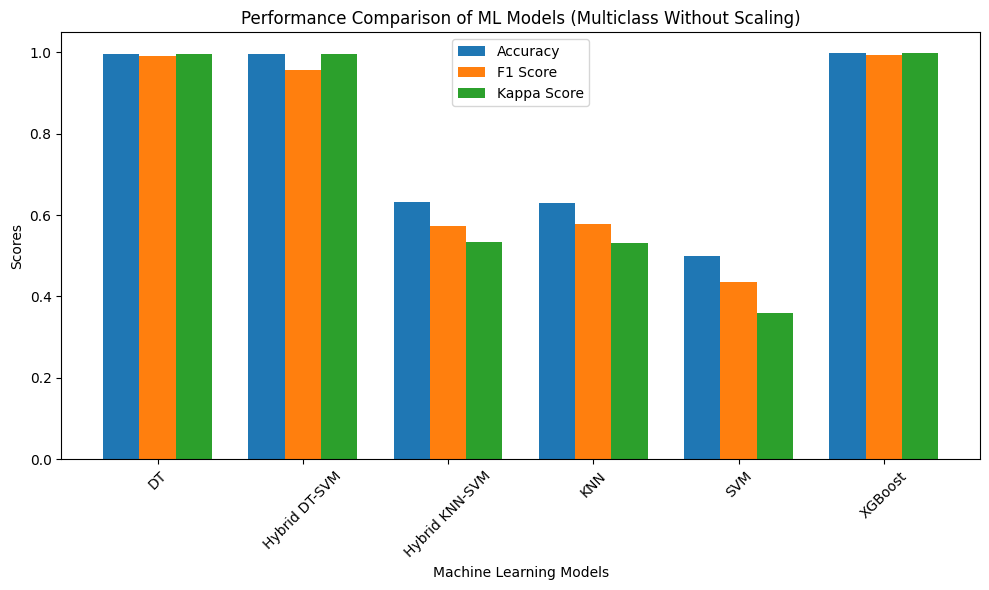

In [38]:
import matplotlib.pyplot as plt
import numpy as np

avg_results = results_df.groupby("Model")[["Accuracy","F1 Score","Kappa Score"]].mean()

models = avg_results.index

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, avg_results["Accuracy"], width, label="Accuracy")
plt.bar(x, avg_results["F1 Score"], width, label="F1 Score")
plt.bar(x + width, avg_results["Kappa Score"], width, label="Kappa Score")

plt.xticks(x, models, rotation=45)

plt.ylabel("Scores")
plt.xlabel("Machine Learning Models")
plt.title("Performance Comparison of ML Models (Multiclass Without Scaling)")

plt.legend()

plt.tight_layout()

plt.show()

## Conclusion

This experiment evaluated multiple machine learning models for **multi-class classification of network traffic without feature scaling**. The models were tested under different **train-test split ratios (70–30, 60–40, 50–50, and 30–70)** to analyze their robustness and generalization performance.

The following models were evaluated:
- Decision Tree (DT)
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- XGBoost
- Hybrid DT–SVM
- Hybrid KNN–SVM

### Key Observations

1. **Tree-based models performed the best.**  
   Decision Tree and XGBoost consistently achieved the highest accuracy, F1 score, and Cohen's Kappa across the different splits. This indicates that tree-based algorithms effectively capture patterns in structured network traffic data.

2. **Hybrid DT–SVM also demonstrated strong performance.**  
   The hybrid DT–SVM model maintained performance close to the standalone Decision Tree model, suggesting that combining models can preserve strong predictive capabilities.

3. **Distance-based models showed moderate performance.**  
   KNN and Hybrid KNN–SVM achieved moderate accuracy compared to tree-based models, which may be due to the sensitivity of distance-based algorithms to feature distributions in high-dimensional datasets.

4. **SVM showed the lowest performance among the evaluated models.**  
   The Support Vector Machine struggled to capture the complex relationships in the dataset without feature scaling, leading to lower accuracy and agreement scores.

### Overall Conclusion

The results indicate that **tree-based algorithms such as Decision Tree and XGBoost are highly effective for multi-class network traffic classification even without feature scaling**. Hybrid models can provide competitive performance but may not always outperform strong standalone models.

Future experiments will evaluate the same models **with feature scaling applied**, allowing a comparison between scaled and non-scaled feature representations to understand their impact on model performance.